In [12]:
from pathlib import Path
from scipy.signal import detrend

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def read_series(path, date_col=0, usecols=None, drop_first_col=False, sort=False):
    df = pd.read_csv(path, parse_dates=[date_col], index_col=date_col, usecols=usecols)
    if drop_first_col:
        df = df.drop(columns=df.columns[0])
    s = df.squeeze()
    return s.sort_index() if sort else s


DATA = Path("/home/py/groundwater/data")
BOW_VALLEY = DATA / "bow_valley"
STREAM = BOW_VALLEY / "stream"

GOWN = pd.read_csv(DATA / "gown" / "combined_absval_20052024_filled.csv", parse_dates=[0], index_col=0)
GOWN.columns = GOWN.columns.astype(int)

marmot_creek_wells = [931, 301, 303, 386, 305]
canmore_wells = [764, 760, 759, 364]

krns = read_series(STREAM / "krns_daily.csv")
bl   = read_series(STREAM / "05BF025_BarrierLk_TAU_Day_Mean.csv")
lkl  = read_series(STREAM / "05BF009.csv")
jcnc = read_series(STREAM / "05BH013.csv", sort=True)
brac_e = read_series(STREAM / "cr.csv", usecols=[0, 2])
brab   = read_series(STREAM / "brab_elevation.csv", usecols=[0, 2])
brac = read_series(STREAM / "cr_flow.csv", date_col=1, drop_first_col=True)

In [15]:
import numpy as np
for _name, _builtin in {"int": int, "float": float, "complex": complex,
                        "bool": bool, "object": object, "str": str}.items():
    if not hasattr(np, _name):
        setattr(np, _name, _builtin)

/tmp/ipykernel_17809/1676316699.py:4: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _name):
/tmp/ipykernel_17809/1676316699.py:4: FutureWarning: In the future `np.str` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _name):


In [16]:
stream_series = {
    'Kananaskis River near Seebe': krns,
    'Kananaskis River below Barrier Lake': bl,
    'Lower Kananaskis Lake': lkl,
    'Bow River at Canmore (Elevation)': brac_e,
    'Bow River at Canmore': brac,
    'Bow River at Banff': brab
}

In [17]:
from sklearn.ensemble import RandomForestRegressor
from tqdm.auto import tqdm

def impute_rf_series(s, n_estimators=200, random_state=0):
    """
    Impute missing values in a single time series using Random Forest.

    Parameters
    ----------
    s            : pd.Series (index=dates)
    n_estimators : int  trees per forest
    random_state : int

    Returns
    -------
    out   : pd.Series  imputed copy of s
    score : float      OOB R² (nan if skipped to interpolation)
    """
    s = s.sort_index().astype(float)
    idx = s.index

    time_feat = pd.DataFrame({
        "t":         np.arange(len(idx)),
        "year":      idx.year,
        "sin_doy":   np.sin(2 * np.pi * idx.dayofyear / 365.25),
        "cos_doy":   np.cos(2 * np.pi * idx.dayofyear / 365.25),
        "sin_month": np.sin(2 * np.pi * idx.month / 12),
        "cos_month": np.cos(2 * np.pi * idx.month / 12),
    }, index=idx)

    m = s.notna()
    miss = ~m
    out = s.copy()

    if m.all():
        return out, 1.0

    if m.sum() < 50:
        out = s.interpolate(method="time").ffill().bfill()
        return out, float("nan")

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_features="sqrt",
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=random_state,
        oob_score=True,
    )
    rf.fit(time_feat.loc[m], s.loc[m])
    score = rf.oob_score_

    out.loc[miss] = rf.predict(time_feat.loc[miss])

    print(f"obs={m.sum()}  missing={miss.sum()}  OOB R²={score:.4f}")
    return out, score

/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Continuous Wavelet Transform

In [18]:
def cwt(s, lab):
    if s.isna().sum() != 0:
        s, _ = impute_rf_series(s)
    x = s.to_numpy().astype(float)
    N  = len(x)
    dt = 1.0 # sampling interval = 1 DAY
    t  = mdates.date2num(s.index.to_pydatetime()) # numeric dates for plotting

    c = np.polyfit(np.arange(N), x, 1)
    x = x - np.polyval(c, np.arange(N)) # remove trend (also removes mean)
    x = x / x.std() # unit variance

    # Morlet parameters and the scale set
    w0 = 6.0
    fourier_factor = 4*np.pi / (w0 + np.sqrt(2 + w0**2)) # scale -> Fourier period
    dj = 0.125
    s0 = 2*dt # smallest scale (~2-day period, Nyquist floor)
    J  = int(np.log2(N*dt/s0) / dj) # scales run up to ~record length
    scales  = s0 * 2**(np.arange(J+1)*dj)
    periods = fourier_factor * scales # in DAYS
    periods_months = periods / 30.4375 # y-axis, in MONTHS (365.25/12)

    # angular frequencies of the DFT
    omega = 2*np.pi*np.fft.fftfreq(N, d=dt)

    # CWT via the Fourier domain
    xhat = np.fft.fft(x)
    W = np.empty((len(scales), N), dtype=complex)
    for i, s in enumerate(scales):
        norm    = np.sqrt(2*np.pi*s/dt) * np.pi**(-0.25)
        psi_hat = norm * np.exp(-0.5*(s*omega - w0)**2) * (omega > 0)
        W[i]    = np.fft.ifft(xhat * psi_hat)
    power = np.abs(W)**2
    power /= scales[:, None] # Liu et al. rectification, for DISPLAY only

    # cone of influence
    edge = (N/2) - np.abs(np.arange(N) - (N-1)/2)  # samples from nearest edge
    coi  = fourier_factor * (edge*dt) / np.sqrt(2)
    coi_months = coi / 30.4375

    fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
    cf = ax.contourf(t, periods_months, power, levels=30, cmap='viridis')
    ax.set_yscale('log')
    ax.set_ylim(periods_months.min(), periods_months.max())
    ax.plot(t, coi_months, 'w--', lw=1)
    ax.fill_between(t, coi_months, periods_months.max(), color='white', alpha=0.3)
    ax.xaxis_date()
    ax.set_xlabel('Date'); ax.set_ylabel('Period (months)')
    ax.set_title(f"{lab}", fontsize=13, fontweight='bold')
    fig.colorbar(cf, label='wavelet power')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout(); plt.show()

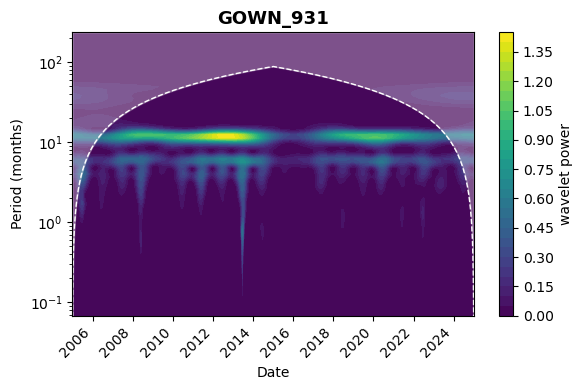

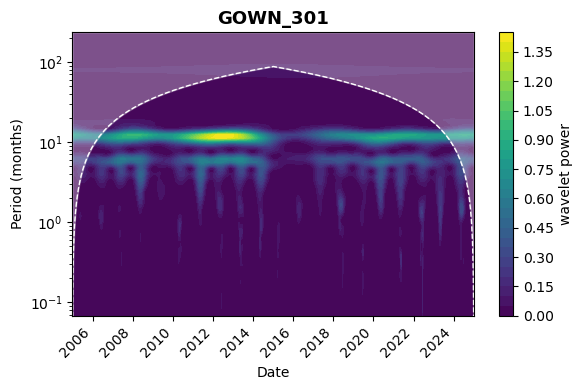

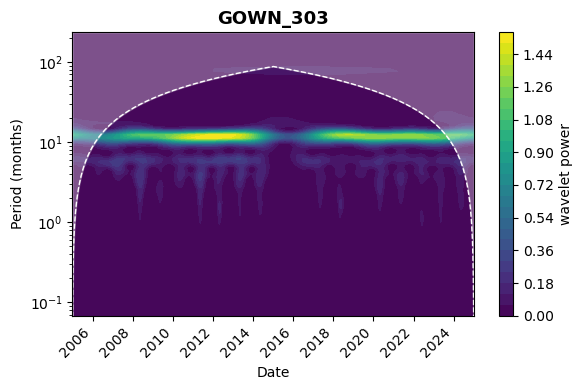

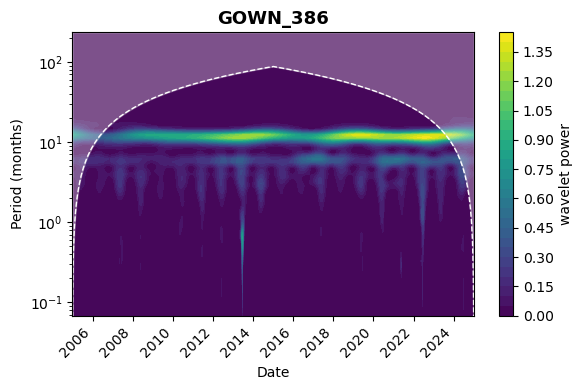

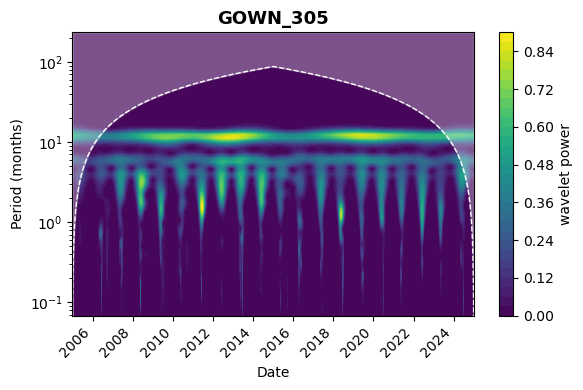

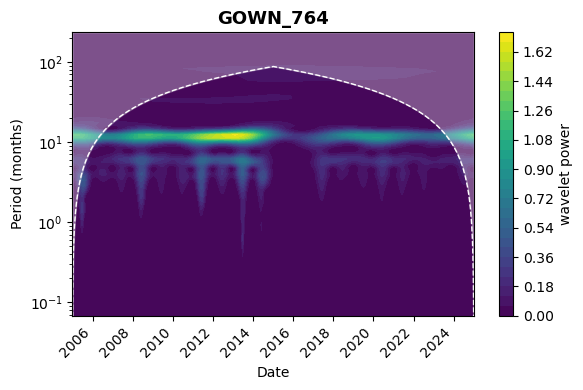

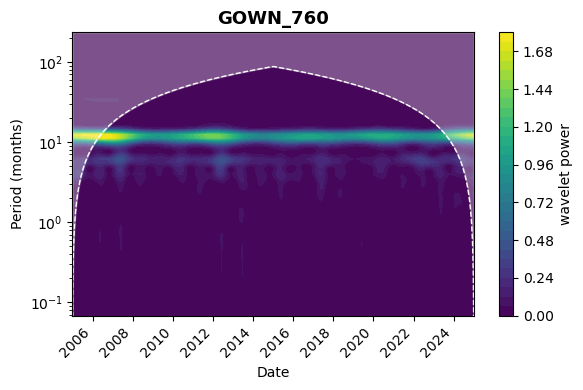

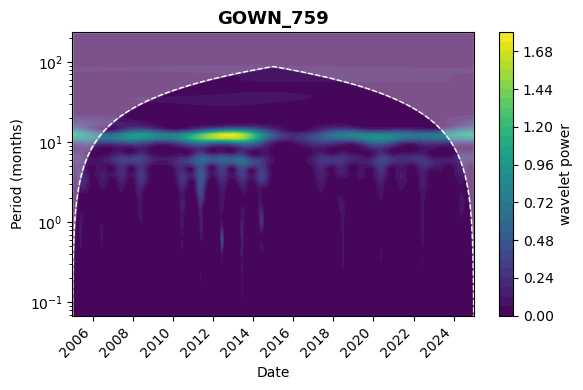

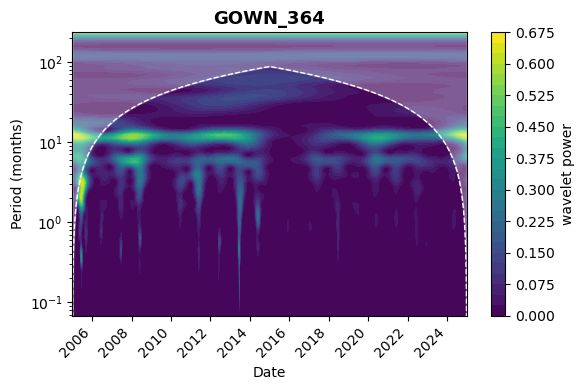

In [9]:
for well in marmot_creek_wells+canmore_wells:
    cwt(GOWN[well], f'GOWN_{well}')

obs=3997  missing=12  OOB R²=0.9612


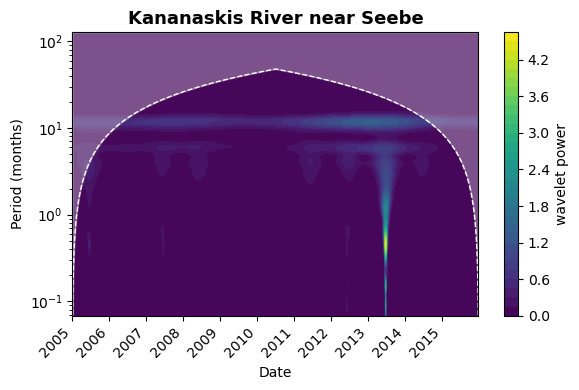

obs=9223  missing=796  OOB R²=0.8932


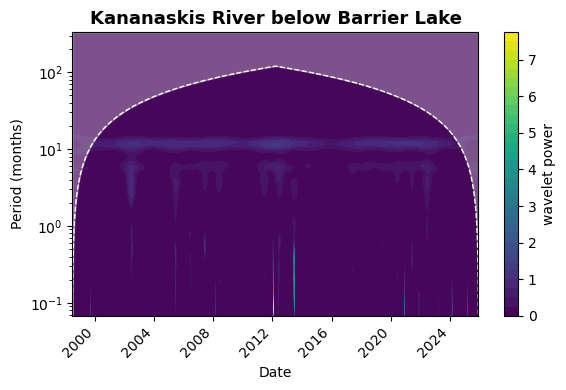

obs=20253  missing=11089  OOB R²=0.9709


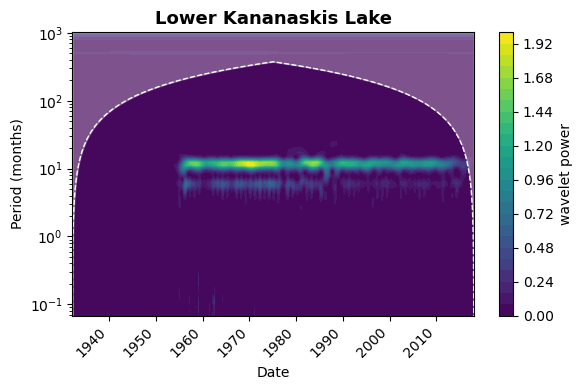

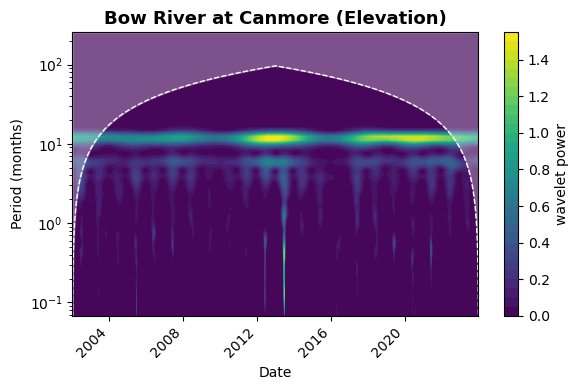

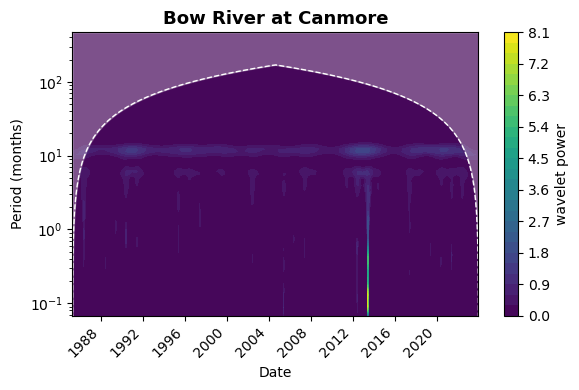

obs=5237  missing=37  OOB R²=0.9782


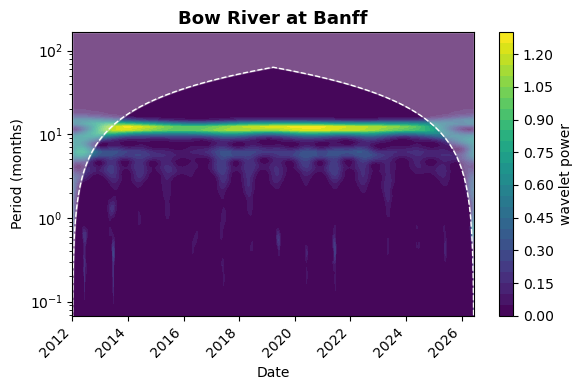

In [10]:
for lab, series in stream_series.items():
    cwt(series, lab)

# Cross-Wavelet Transform (XWT)

In [19]:
# --- shared single-series transform, factored out of your cwt() ---------
def _detrend_norm(s):
    x = s.to_numpy().astype(float)
    n = len(x)
    x = x - np.polyval(np.polyfit(np.arange(n), x, 1), np.arange(n))  # detrend
    return x / x.std()                                                # unit variance

def _cwt_core(x, scales, omega, w0, dt):
    xhat = np.fft.fft(x)
    W = np.empty((len(scales), len(x)), dtype=complex)
    for i, s in enumerate(scales):
        norm    = np.sqrt(2*np.pi*s/dt) * np.pi**(-0.25)
        psi_hat = norm * np.exp(-0.5*(s*omega - w0)**2) * (omega > 0)
        W[i]    = np.fft.ifft(xhat * psi_hat)
    return W

def xwt(s1, s2, lab1, lab2):
    # ---- 1. put both series on ONE evenly-spaced daily grid ------------
    start, end = max(s1.index.min(), s2.index.min()), min(s1.index.max(), s2.index.max())
    idx = pd.date_range(start, end, freq='D')          # daily; guarantees even dt
    s1, s2 = s1.reindex(idx), s2.reindex(idx)
    if s1.isna().sum(): s1, _ = impute_rf_series(s1)
    if s2.isna().sum(): s2, _ = impute_rf_series(s2)

    dt, N = 1.0, len(idx)
    t = mdates.date2num(idx.to_pydatetime())

    # ---- 2. preprocess each series independently ----------------------
    x1, x2 = _detrend_norm(s1), _detrend_norm(s2)

    # ---- 3. shared scale set (same for both, required) ----------------
    w0 = 6.0
    fourier_factor = 4*np.pi / (w0 + np.sqrt(2 + w0**2))
    dj, s0 = 0.125, 2*dt
    J = int(np.log2(N*dt/s0) / dj)
    scales = s0 * 2**(np.arange(J+1)*dj)
    periods_months = fourier_factor * scales / 30.4375
    omega = 2*np.pi*np.fft.fftfreq(N, d=dt)

    # ---- 4. two transforms -> cross spectrum -------------------------
    W1, W2 = _cwt_core(x1, scales, omega, w0, dt), _cwt_core(x2, scales, omega, w0, dt)
    Wxy   = W1 * np.conj(W2)                    # complex cross-wavelet spectrum
    power = np.abs(Wxy) / scales[:, None]       # rectified cross power (display)
    phase = np.angle(Wxy)                       # relative phase (unaffected by rectification)

    # ---- 5. COI -------------------------------------------------------
    edge = (N/2) - np.abs(np.arange(N) - (N-1)/2)
    coi_months = fourier_factor * (edge*dt) / np.sqrt(2) / 30.4375

    # ---- 6. plot: power + phase arrows -------------------------------
    fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
    cf = ax.contourf(t, periods_months, power, levels=30, cmap='viridis')
    ax.set_yscale('log'); ax.set_ylim(periods_months.min(), periods_months.max())

    T, P = np.meshgrid(t, periods_months)                     # both (nscales, N)
    st, ss = max(N//30, 1), max(len(scales)//20, 1)           # arrow strides
    keep = np.zeros_like(phase, bool); keep[::ss, ::st] = True
    keep &= (P <= coi_months[None, :])                        # outside COI only
    keep &= (power > np.percentile(power, 75))                # only where common power is real
    ax.quiver(T[keep], P[keep], np.cos(phase[keep]), np.sin(phase[keep]),
              angles='uv', pivot='mid', scale=30, width=0.003, color='w', alpha=0.9)

    ax.plot(t, coi_months, 'w--', lw=1)
    ax.fill_between(t, coi_months, periods_months.max(), color='white', alpha=0.3)
    ax.xaxis_date()
    ax.set_xlabel('Date'); ax.set_ylabel('Period (months)')
    ax.set_title(f"XWT: {lab1} vs {lab2}", fontsize=13, fontweight='bold')
    fig.colorbar(cf, label='cross power  |Wxy| / scale')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout(); plt.show()

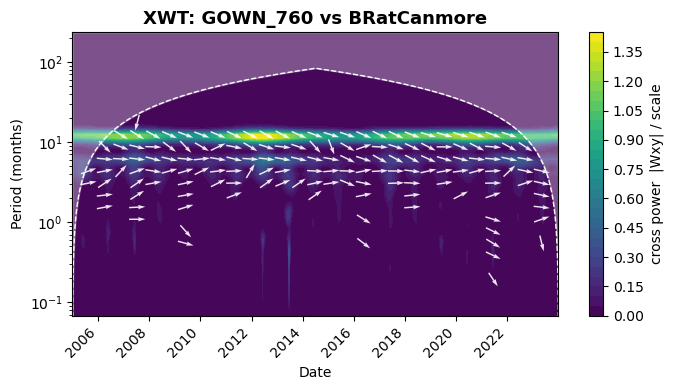

In [12]:
xwt(GOWN[760], brac_e, 'GOWN_760', 'BRatCanmore')

# Using pycwt

In [1]:
import pycwt as wavelet

In [2]:
import numpy as np, pycwt, pycwt.wavelet, pycwt.helpers

def _lag1(y):                       # plain, always-defined lag-1 autocorrelation
    y = np.asarray(y, float); y = y - y.mean()
    return float(np.clip(np.corrcoef(y[:-1], y[1:])[0, 1], -0.999, 0.999))

def _robust_ar1(x):                 # drop-in for pycwt's ar1; matches its 3-tuple
    return _lag1(x), 1.0, 0.0       # callers only use the first element

pycwt.wavelet.ar1 = _robust_ar1     # <- the one xwt/wct/significance call internally
pycwt.helpers.ar1 = _robust_ar1
pycwt.ar1         = _robust_ar1

In [3]:
MONTH = 30.4375  # mean days/month = 365.25/12

In [4]:
def _detrend(y):
    n = len(y)
    return y - np.polyval(np.polyfit(np.arange(n), y, 1), np.arange(n))

In [51]:
def _fmt(ax, t, per_m, coi_m, title, yticks=(0.1, 0.3, 1, 3, 6, 12, 24, 60, 120)):
    ax.set_yscale('log')
    ax.set_ylim(per_m.min(), per_m.max())

    ax.plot(t, coi_m, 'w--', lw=1)
    ax.fill_between(t, coi_m, per_m.max(), color='white', alpha=0.3)

    ax.xaxis_date(); ax.set_xlabel('Date')

    yt = [y for y in yticks if per_m.min() <= y <= per_m.max()]  # drop out-of-range ticks
    ax.set_yticks(yt)
    ax.set_yticklabels([f"{y:g}" for y in yt])                  # plain numbers, no sci notation

    ax.set_ylabel('Period (months)')
    ax.set_title(title, fontsize=12, fontweight='bold')

    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

In [60]:
def _arrows(ax, t, per_m, coi_m, phase, mask_field, thresh):
    T, P = np.meshgrid(t, per_m)
    ss, stp = max(len(per_m)//20, 1), max(len(t)//30, 1)
    keep = np.zeros_like(phase, bool); keep[::ss, ::stp] = True
    keep &= (P <= coi_m[None, :]) & (mask_field >= thresh)   # only outside COI & where real
    ax.quiver(T[keep], P[keep], np.cos(phase[keep]), np.sin(phase[keep]),
              pivot='mid', scale=30, width=0.003, color='black')

## CWT

In [8]:
def plot_cwt(s, lab, dj=1/12, rectify=True):
    y = _detrend(s.to_numpy().astype(float)); y /= y.std()
    t = mdates.date2num(s.index.to_pydatetime()); dt = 1.0

    mother = wavelet.Morlet(6)
    # alpha, _, _ = wavelet.ar1(y)
    alpha = _lag1(y)

    W, sj, freq, coi, _, _ = wavelet.cwt(y, dt, dj, -1, -1, mother)   # s0,J default
    power = np.abs(W)**2
    per_m, coi_m = (1/freq)/MONTH, coi/MONTH
    disp = power/sj[:, None] if rectify else power                    # rectify: DISPLAY only

    signif, _ = wavelet.significance(1.0, dt, sj, 0, alpha, wavelet=mother)
    sig = power / signif[:, None]                                     # test: UN-rectified

    fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
    cf = ax.contourf(t, per_m, disp, levels=30, cmap='viridis')
    ax.contour(t, per_m, sig, [1], colors='k', linewidths=1)
    _fmt(ax, t, per_m, coi_m, lab)
    fig.colorbar(cf, label='|W|²/scale' if rectify else '|W|²')
    plt.tight_layout(); plt.show()
    return W, sj, freq, coi

In [13]:
for well in marmot_creek_wells + canmore_wells:
    y = GOWN[well].to_numpy().astype(float)
    yd = y - np.polyval(np.polyfit(np.arange(len(y)), y, 1), np.arange(len(y)))
    print(f"{well:>8}  N={len(y):>5}  detrended lag-1 = {_lag1(yd):.4f}")

     931  N= 7305  detrended lag-1 = 0.9983
     301  N= 7305  detrended lag-1 = 0.9959
     303  N= 7305  detrended lag-1 = 0.9990
     386  N= 7305  detrended lag-1 = 0.9962
     305  N= 7305  detrended lag-1 = 0.9902
     764  N= 7305  detrended lag-1 = 0.9990
     760  N= 7305  detrended lag-1 = 0.9987
     759  N= 7305  detrended lag-1 = 0.9950
     364  N= 7305  detrended lag-1 = 0.9978


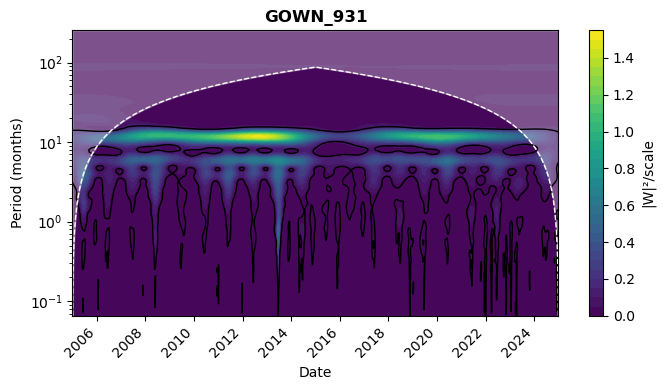

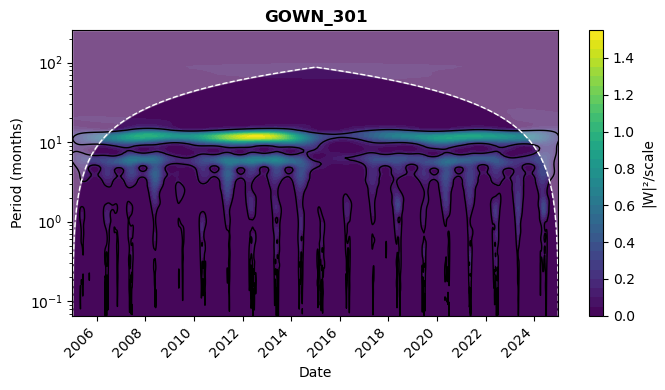

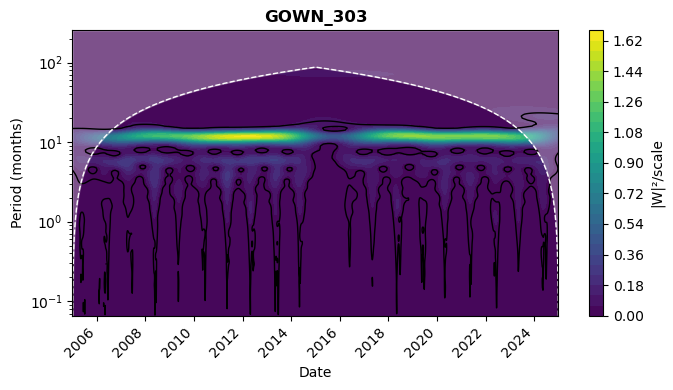

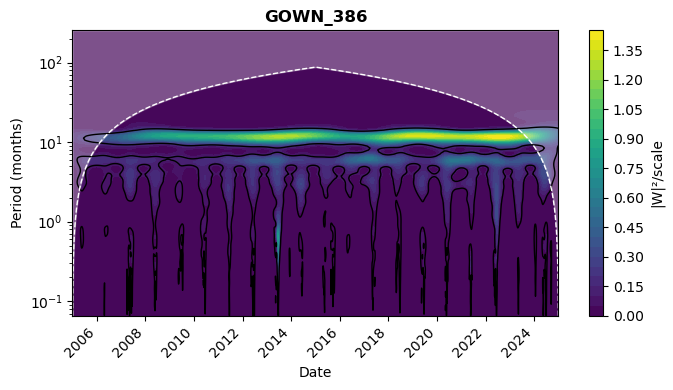

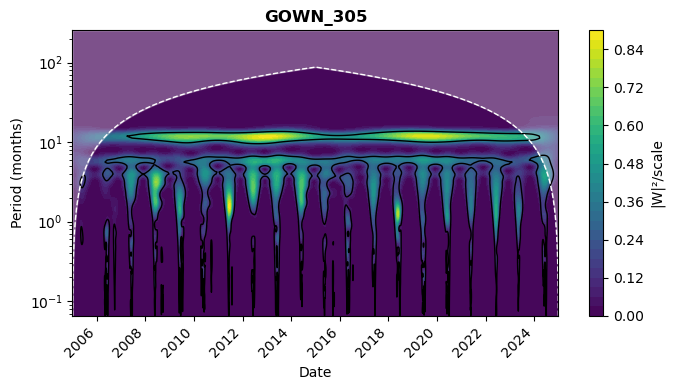

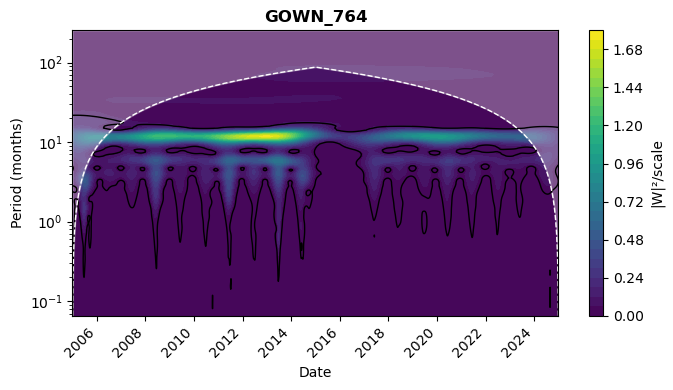

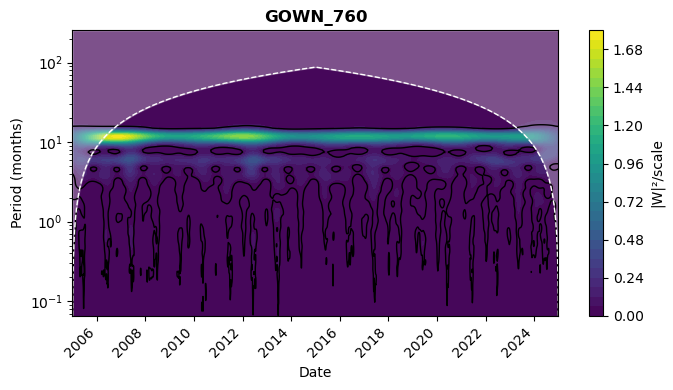

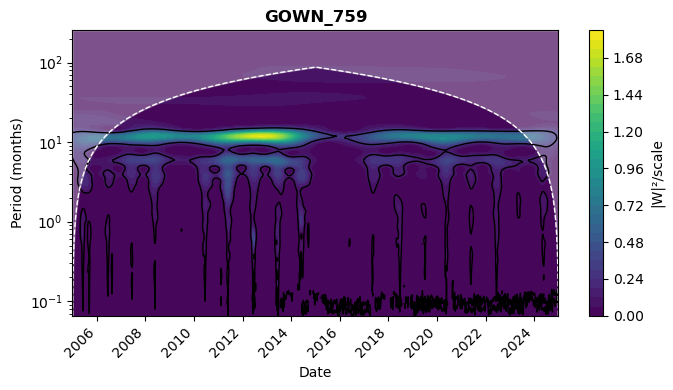

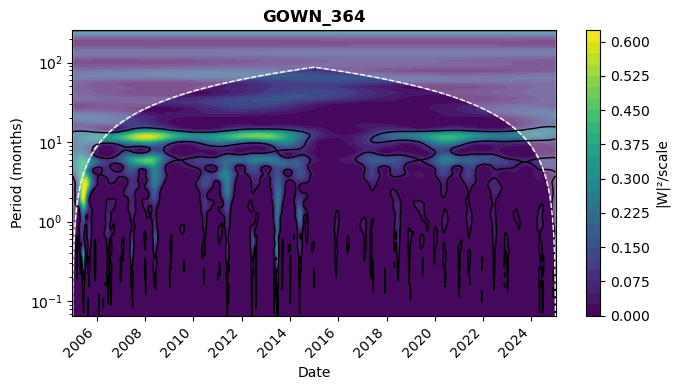

In [22]:
for well in marmot_creek_wells+canmore_wells:
    plot_cwt(GOWN[well], f'GOWN_{well}')

## XWT

In [23]:
def plot_xwt(s1, s2, lab1, lab2, dj=1/12, siglvl=0.95):
    idx = s1.index.intersection(s2.index)                            # REQUIRED: equal length
    y1, y2 = _detrend(s1.loc[idx].to_numpy().astype(float)), _detrend(s2.loc[idx].to_numpy().astype(float))
    t = mdates.date2num(idx.to_pydatetime()); dt = 1.0
    mother = wavelet.Morlet(6)
    W12, coi, freq, signif = wavelet.xwt(y1, y2, dt, dj=dj, s0=-1, J=-1,
                                         significance_level=siglvl,
                                         wavelet=mother, normalize=True)
    power, phase = np.abs(W12), np.angle(W12)
    per_m, coi_m = (1/freq)/MONTH, coi/MONTH
    sig = power / signif[:, None]

    fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
    cf = ax.contourf(t, per_m, power, levels=30, cmap='viridis')
    ax.contour(t, per_m, sig, [1], colors='k', linewidths=1)
    _arrows(ax, t, per_m, coi_m, phase, sig, 1)                      # arrows where significant
    _fmt(ax, t, per_m, coi_m, f"XWT: {lab1} vs {lab2}")
    fig.colorbar(cf, label='cross power |W₁₂|')
    plt.tight_layout(); plt.show()
    return W12, coi, freq

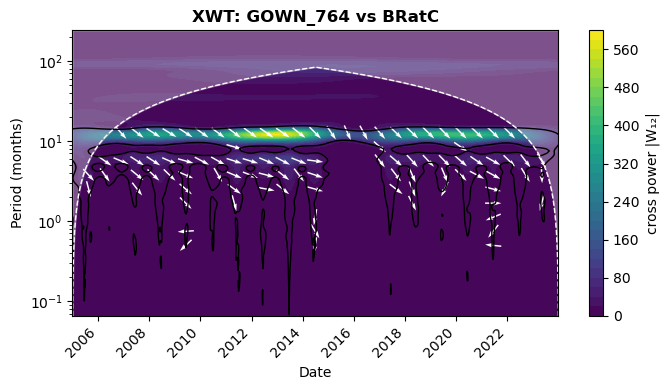

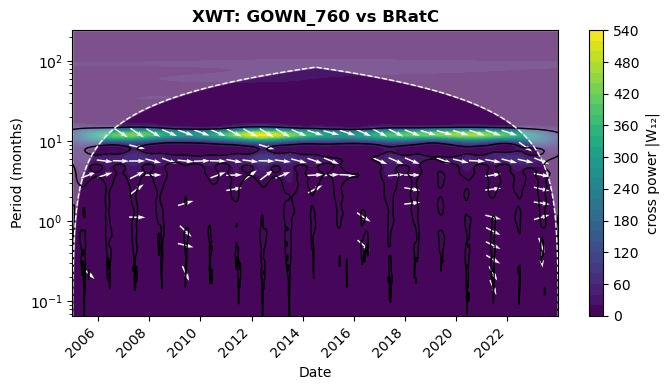

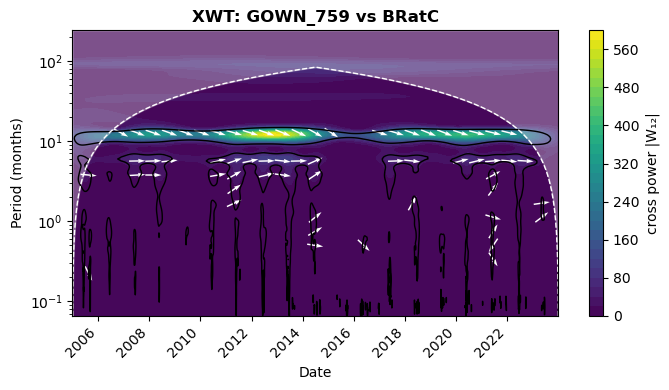

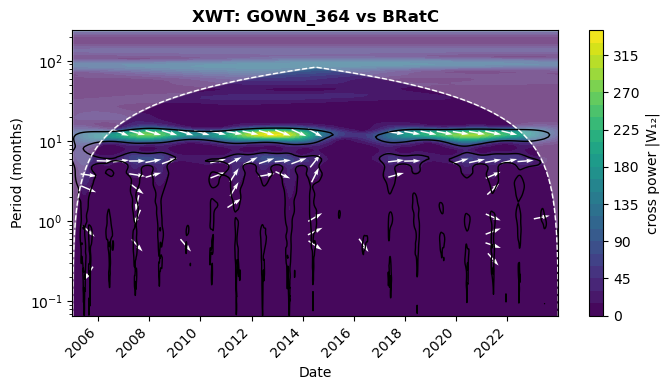

In [24]:
for well in canmore_wells:
    plot_xwt(GOWN[well], brac_e, f'GOWN_{well}', 'BRatC')

In [25]:
krns_filled, _ = impute_rf_series(krns)

obs=3997  missing=12  OOB R²=0.9612


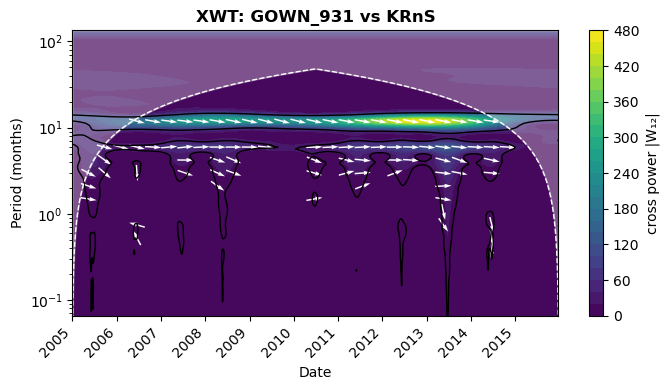

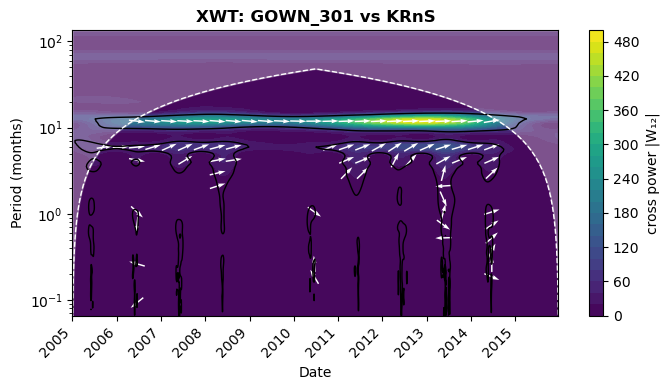

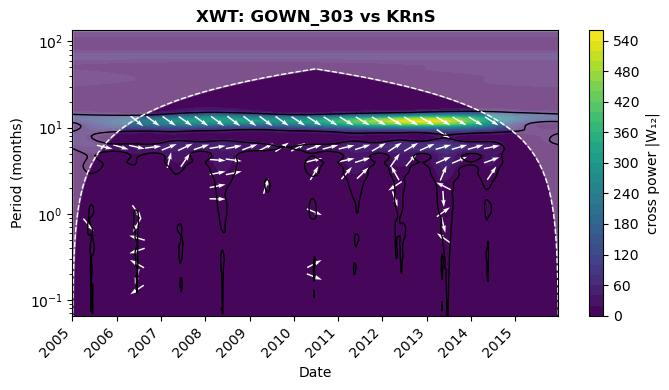

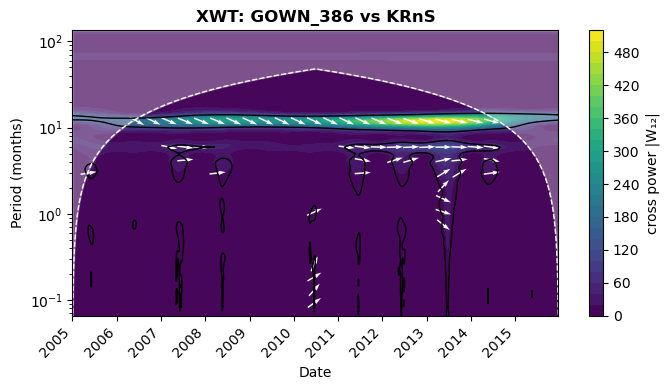

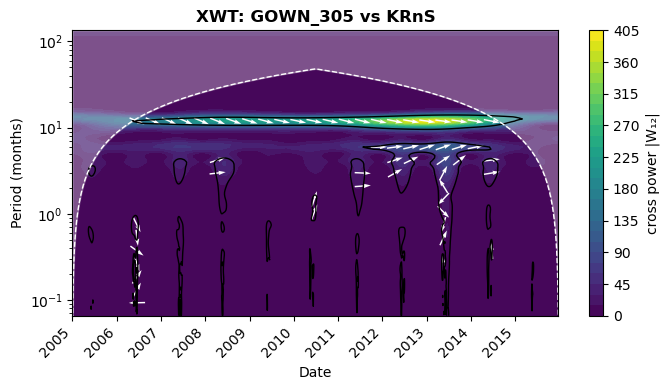

In [26]:
for well in marmot_creek_wells:
    plot_xwt(GOWN[well], krns_filled, f'GOWN_{well}', 'KRnS')

## WCT

In [61]:
def plot_wct(s1, s2, lab1, lab2, dj=1/12, mc_count=300, sig=False, max_period_yr=None):
    idx = s1.index.intersection(s2.index)
    y1, y2 = _detrend(s1.loc[idx].to_numpy().astype(float)), _detrend(s2.loc[idx].to_numpy().astype(float))
    t = mdates.date2num(idx.to_pydatetime()); dt = 1.0
    mother = wavelet.Morlet(6)

    dt = 1.0
    J = -1 if max_period_yr is None else int(np.log2(max_period_yr*365.25/(2*dt)) / dj)

    WCT, aWCT, coi, freq, sig95 = wavelet.wct(y1, y2, dt, dj=dj, s0=-1, J=J,
                                              sig=sig, significance_level=0.95,
                                              wavelet=mother, normalize=True,
                                              mc_count=mc_count)      # Monte Carlo: slow 1st run

    per_m, coi_m = (1/freq)/MONTH, coi/MONTH
    # per_d, coi_d = 1/freq, coi

    fig, ax = plt.subplots(figsize=(7, 4), dpi=100)

    if sig and np.asarray(sig95).size > 1:
        ax.contour(t, per_m, WCT / sig95[:, None], [1], colors='k', linewidths=1)

    cf = ax.contourf(t, per_m, WCT, levels=np.linspace(0, 1, 11), cmap='viridis')
    if np.asarray(sig95).size > 1:
        ax.contour(t, per_m, WCT / sig95[:, None], [1], colors='k', linewidths=1)
    _arrows(ax, t, per_m, coi_m, aWCT, WCT, 0.5)                     # arrows where coherent
    _fmt(ax, t, per_m, coi_m, f"WCT: {lab1} vs {lab2}")
    fig.colorbar(cf, label='coherence')
    plt.tight_layout(); plt.show()
    return WCT, aWCT, coi, freq

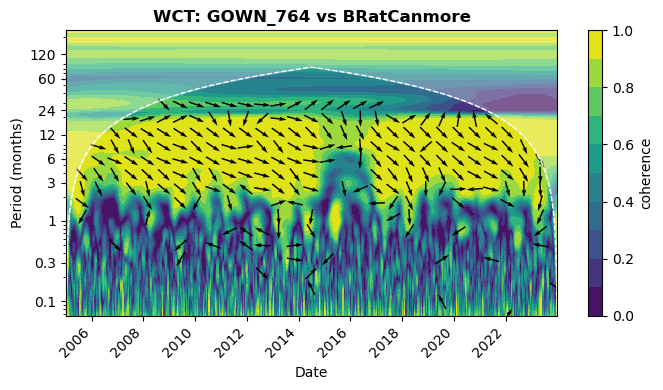

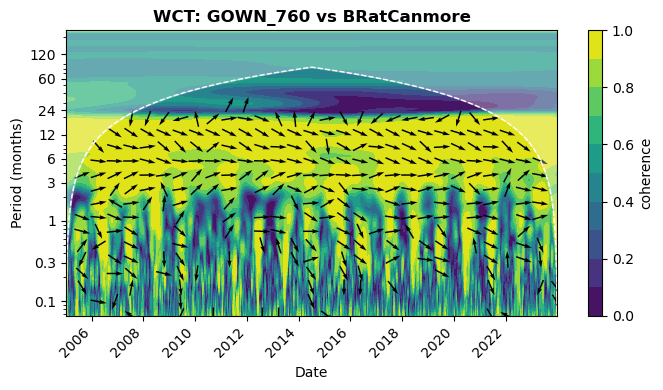

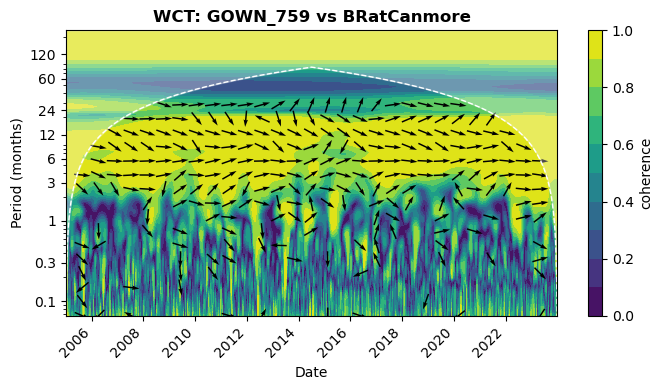

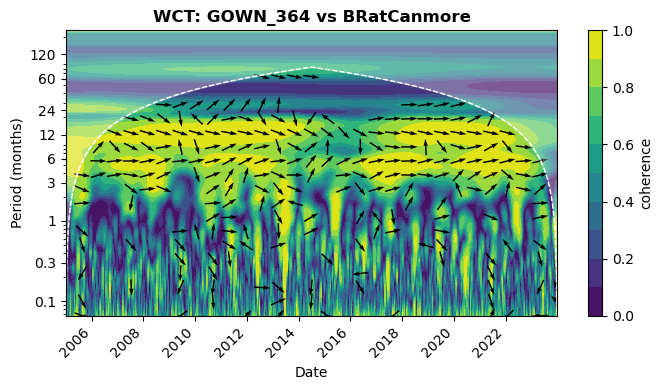

In [62]:
for well in canmore_wells:
    plot_wct(GOWN[well], brac_e, f'GOWN_{well}', 'BRatCanmore')

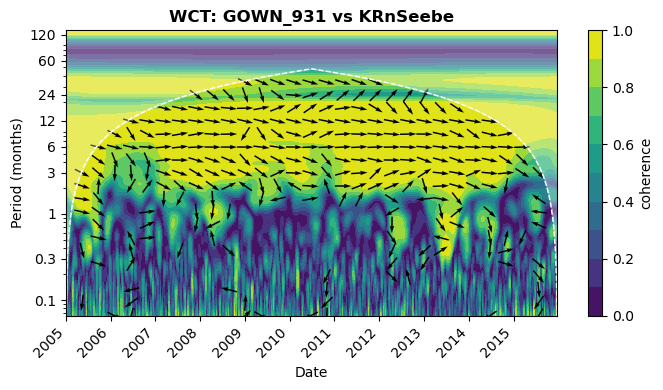

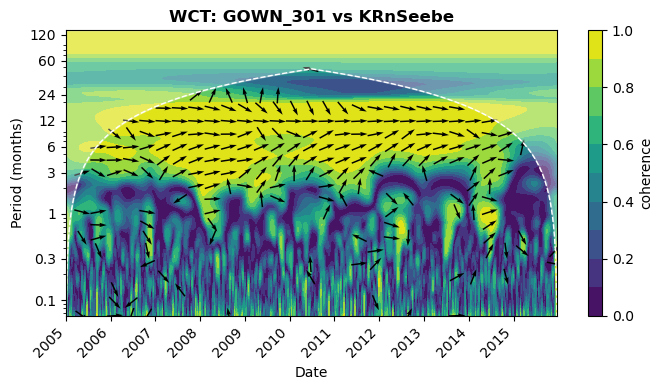

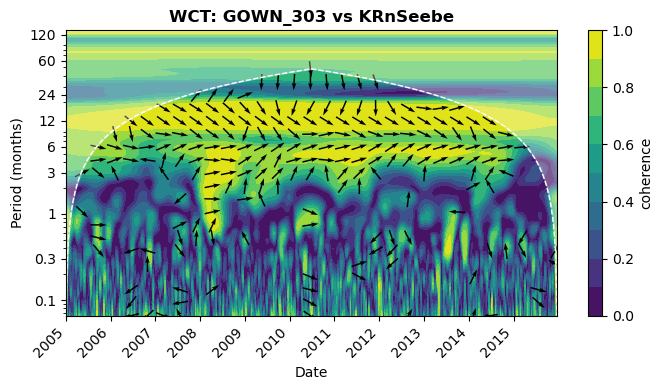

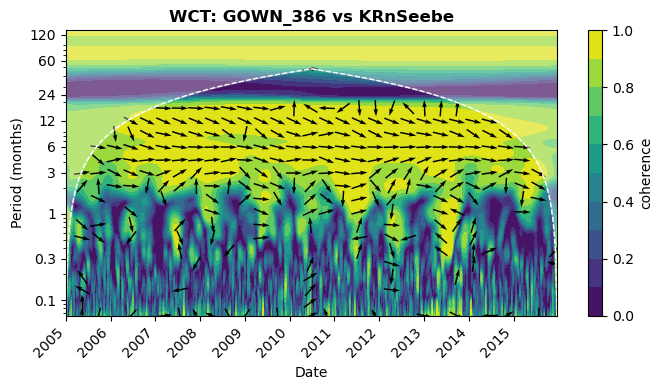

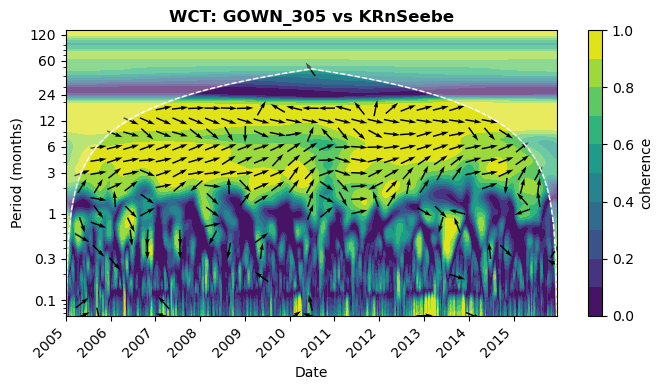

In [63]:
for well in marmot_creek_wells:
    plot_wct(GOWN[well], krns_filled, f'GOWN_{well}', 'KRnSeebe')

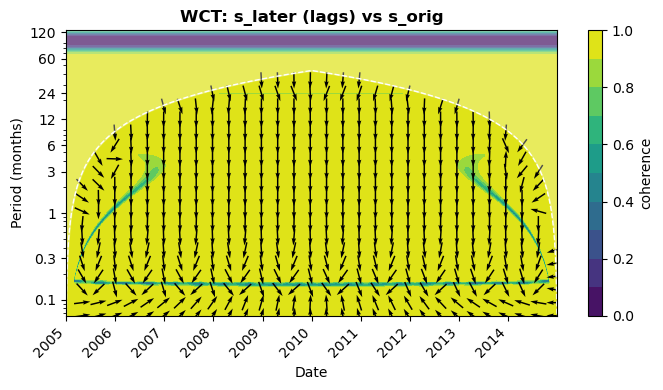

(array([[0.99983712, 0.99982183, 0.99980254, ..., 0.99971895, 0.99974625,
         0.99976791],
        [0.99979192, 0.99977591, 0.99975534, ..., 0.9996518 , 0.99968088,
         0.99970354],
        [0.99973785, 0.9997211 , 0.9996992 , ..., 0.99957195, 0.99960288,
         0.99962656],
        ...,
        [0.16495005, 0.16495001, 0.16494996, ..., 0.16493942, 0.16493952,
         0.16493961],
        [0.43281594, 0.43281591, 0.43281587, ..., 0.43280992, 0.43280998,
         0.43281004],
        [0.77986007, 0.77986006, 0.77986005, ..., 0.77985885, 0.77985887,
         0.77985888]], shape=(132, 3650)),
 array([[-0.0134045 , -0.01101629, -0.00743729, ..., -3.13272485,
         -3.12844019, -3.12556523],
        [-0.01729913, -0.01501246, -0.01145665, ..., -3.12793606,
         -3.12367253, -3.12091128],
        [-0.0219231 , -0.01981032, -0.01642389, ..., -3.12202047,
         -3.11794993, -3.11538686],
        ...,
        [ 1.79518378,  1.79518496,  1.79518613, ...,  1.79467734,
     

In [64]:
idx = pd.date_range('2005-01-01', periods=3650, freq='D')
k   = np.arange(3650)
T   = 365.0
lag = T/4                                   # quarter period -> 90° at the annual band
s_orig  = pd.Series(np.sin(2*np.pi* k        /T), idx)
s_later = pd.Series(np.sin(2*np.pi*(k - lag)  /T), idx)   # peaks LATER -> s_later LAGS s_orig

plot_wct(s_later, s_orig, 's_later (lags)', 's_orig')